# AI-Powered Retail Sales Analytics and Sales Prediction

## Walmart Store Sales Forecasting - Comprehensive Analysis

---

### Project Overview

This notebook presents a **complete end-to-end analysis** of the Walmart Store Sales Forecasting dataset. The goal is to understand historical sales patterns across 45 stores and 81 departments, identify key drivers of sales, and build machine learning models to predict future weekly sales.

### Why Retail Sales Prediction Matters

- **Inventory Optimization**: Accurate forecasts reduce overstock and stockout costs
- **Staffing Decisions**: Align labor allocation with expected demand
- **Promotional Planning**: Quantify the impact of holidays and markdowns
- **Financial Forecasting**: Enable accurate revenue projections

### Approach

1. **Data Analytics**: Explore patterns through comprehensive EDA
2. **Feature Engineering**: Create meaningful features from raw data
3. **Machine Learning**: Train and compare multiple regression models
4. **Insights Generation**: Extract actionable business recommendations

### Dataset Files

| File | Description |
|------|-------------|
| `train.csv` | Historical weekly sales per store-department (target: `Weekly_Sales`) |
| `test.csv` | Future weeks requiring predictions |
| `features.csv` | Store-level weekly features (economic indicators + markdowns) |
| `stores.csv` | Store metadata (type and size) |


---
## 1. Setup and Dataset Loading

Import all required libraries and load the four core CSV files.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print("All libraries imported successfully.")


All libraries imported successfully.


In [2]:
# ── Load Datasets ────────────────────────────────────────────────────────────
# CSV files are in the project root (parent of notebooks/)
import os
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), '')
# Handle case where notebook is run from project root
if not os.path.exists(os.path.join(DATA_DIR, 'train.csv')):
    DATA_DIR = ''

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
features = pd.read_csv(os.path.join(DATA_DIR, 'features.csv'))
stores = pd.read_csv(os.path.join(DATA_DIR, 'stores.csv'))

print(f"train.csv:    {train.shape[0]:>10,} rows x {train.shape[1]} cols")
print(f"test.csv:     {test.shape[0]:>10,} rows x {test.shape[1]} cols")
print(f"features.csv: {features.shape[0]:>10,} rows x {features.shape[1]} cols")
print(f"stores.csv:   {stores.shape[0]:>10,} rows x {stores.shape[1]} cols")


train.csv:       421,570 rows x 5 cols
test.csv:        115,064 rows x 4 cols
features.csv:      8,190 rows x 12 cols
stores.csv:           45 rows x 3 cols


---
## 2. Dataset Structure and Statistics

Let's examine each dataset's columns, data types, and summary statistics.


In [3]:
# ── train.csv ────────────────────────────────────────────────────────────────
print("=" * 60)
print("TRAIN.CSV")
print("=" * 60)
print(f"\nColumns: {list(train.columns)}")
print(f"\nData Types:\n{train.dtypes}")
print(f"\nDate Range: {train['Date'].min()} to {train['Date'].max()}")
print(f"Unique Stores: {train['Store'].nunique()}")
print(f"Unique Departments: {train['Dept'].nunique()}")
print(f"\nIsHoliday Distribution:\n{train['IsHoliday'].value_counts()}")
print(f"\nWeekly_Sales Statistics:")
print(train['Weekly_Sales'].describe())
print(f"\nNegative Sales Count: {(train['Weekly_Sales'] < 0).sum()}")
print(f"Zero Sales Count: {(train['Weekly_Sales'] == 0).sum()}")


TRAIN.CSV

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Data Types:
Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
dtype: object

Date Range: 2010-02-05 to 2012-10-26
Unique Stores: 45
Unique Departments: 81

IsHoliday Distribution:
IsHoliday
False    391909
True      29661
Name: count, dtype: int64

Weekly_Sales Statistics:
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

Negative Sales Count: 1285
Zero Sales Count: 73


In [4]:
# ── test.csv ─────────────────────────────────────────────────────────────────
print("=" * 60)
print("TEST.CSV")
print("=" * 60)
print(f"\nColumns: {list(test.columns)}")
print(f"Date Range: {test['Date'].min()} to {test['Date'].max()}")
print(f"Unique Stores: {test['Store'].nunique()}")
print(f"Unique Departments: {test['Dept'].nunique()}")
print(f"\nNote: test.csv does NOT contain Weekly_Sales (that's what we predict)")


TEST.CSV

Columns: ['Store', 'Dept', 'Date', 'IsHoliday']
Date Range: 2012-11-02 to 2013-07-26
Unique Stores: 45
Unique Departments: 81

Note: test.csv does NOT contain Weekly_Sales (that's what we predict)


In [5]:
# ── features.csv ─────────────────────────────────────────────────────────────
print("=" * 60)
print("FEATURES.CSV")
print("=" * 60)
print(f"\nColumns: {list(features.columns)}")
print(f"Date Range: {features['Date'].min()} to {features['Date'].max()}")
print(f"\nSummary Statistics:")
features.describe()


FEATURES.CSV

Columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']
Date Range: 2010-02-05 to 2013-07-26

Summary Statistics:


,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


In [6]:
# ── stores.csv ───────────────────────────────────────────────────────────────
print("=" * 60)
print("STORES.CSV")
print("=" * 60)
print(f"\nStore Type Distribution:")
print(stores['Type'].value_counts())
print(f"\nStore Size Statistics:")
print(stores['Size'].describe())
print(f"\nFull stores.csv content:")
stores


STORES.CSV

Store Type Distribution:
Type
A    22
B    17
C     6
Name: count, dtype: int64

Store Size Statistics:
count        45.000000
mean     130287.600000
std       63825.271991
min       34875.000000
25%       70713.000000
50%      126512.000000
75%      202307.000000
max      219622.000000
Name: Size, dtype: float64

Full stores.csv content:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


---
## 3. Data Quality and Missing Value Analysis

Check for missing values, duplicates, and data integrity issues.


In [7]:
# ── Missing Values Summary ────────────────────────────────────────────────────
print("MISSING VALUES PER DATASET")
print("=" * 60)

for name, df in [("train", train), ("test", test), ("features", features), ("stores", stores)]:
    missing = df.isnull().sum()
    total_missing = missing.sum()
    print(f"\n{name}.csv (Total missing: {total_missing:,}):")
    if total_missing == 0:
        print("  No missing values.")
    else:
        for col in missing[missing > 0].index:
            pct = missing[col] / len(df) * 100
            print(f"  {col}: {missing[col]:,} ({pct:.1f}%)")


MISSING VALUES PER DATASET

train.csv (Total missing: 0):
  No missing values.

test.csv (Total missing: 0):
  No missing values.

features.csv (Total missing: 24,040):
  MarkDown1: 4,158 (50.8%)
  MarkDown2: 5,269 (64.3%)
  MarkDown3: 4,577 (55.9%)
  MarkDown4: 4,726 (57.7%)
  MarkDown5: 4,140 (50.5%)
  CPI: 585 (7.1%)
  Unemployment: 585 (7.1%)

stores.csv (Total missing: 0):
  No missing values.


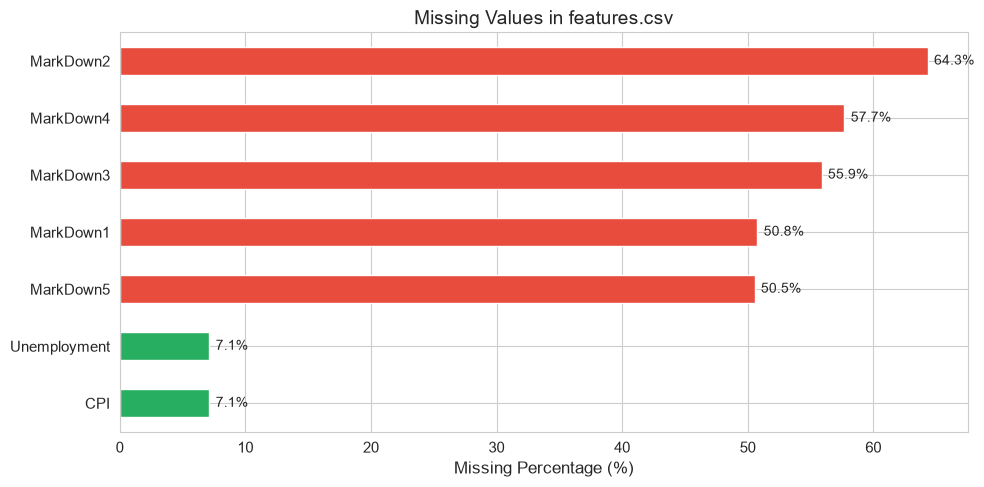


Key Observations:
- MarkDown columns have 50-64% missing values (promotions started later)
- CPI and Unemployment have 7.1% missing (some stores lack economic data)
- train.csv, test.csv, and stores.csv have NO missing values


In [8]:
# ── Visualize Missing Values in features.csv ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
missing_pct = (features.isnull().sum() / len(features) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 10 else '#27ae60' for v in missing_pct.values]
missing_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values in features.csv')
for i, (val, name) in enumerate(zip(missing_pct.values, missing_pct.index)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- MarkDown columns have 50-64% missing values (promotions started later)")
print("- CPI and Unemployment have 7.1% missing (some stores lack economic data)")
print("- train.csv, test.csv, and stores.csv have NO missing values")


In [9]:
# ── Duplicate Rows Check ──────────────────────────────────────────────────────
print("DUPLICATE ROWS CHECK")
print("=" * 60)
for name, df in [("train", train), ("test", test), ("features", features), ("stores", stores)]:
    dups = df.duplicated().sum()
    print(f"  {name}.csv: {dups} duplicates")

# ── Date Overlap Check ───────────────────────────────────────────────────────
train_dates = set(train['Date'].unique())
test_dates = set(test['Date'].unique())
overlap = train_dates & test_dates
print(f"\nTrain/Test date overlap: {len(overlap)} dates")
print("  -> No overlap: train ends before test begins (clean temporal split)")


DUPLICATE ROWS CHECK
  train.csv: 0 duplicates
  test.csv: 0 duplicates
  features.csv: 0 duplicates
  stores.csv: 0 duplicates

Train/Test date overlap: 0 dates
  -> No overlap: train ends before test begins (clean temporal split)


---
## 4. Data Cleaning

Handle missing values and parse dates. Strategy:
- **MarkDown1-5**: Fill with 0 (missing = no promotion was active)
- **CPI / Unemployment**: Forward-fill then backward-fill per store (these change slowly over time)
- **Date**: Convert to datetime type


In [10]:
# ── Parse Dates ──────────────────────────────────────────────────────────────
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])
features['Date'] = pd.to_datetime(features['Date'])

print("Dates parsed to datetime.")
print(f"  Train:    {train['Date'].min().date()} to {train['Date'].max().date()}")
print(f"  Test:     {test['Date'].min().date()} to {test['Date'].max().date()}")
print(f"  Features: {features['Date'].min().date()} to {features['Date'].max().date()}")


Dates parsed to datetime.
  Train:    2010-02-05 to 2012-10-26
  Test:     2012-11-02 to 2013-07-26
  Features: 2010-02-05 to 2013-07-26


In [11]:
# ── Handle Missing Values in features.csv ────────────────────────────────────
md_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Fill markdowns with 0
for col in md_cols:
    n = features[col].isna().sum()
    features[col] = features[col].fillna(0)
    print(f"Filled {n:,} missing values in {col} with 0")

# Forward-fill + backward-fill CPI and Unemployment per store
for col in ['CPI', 'Unemployment']:
    n = features[col].isna().sum()
    features[col] = features.groupby('Store')[col].transform(lambda s: s.ffill().bfill())
    remaining = features[col].isna().sum()
    print(f"Filled {n - remaining:,}/{n:,} missing values in {col} via ffill+bfill")

print(f"\nRemaining missing values in features.csv: {features.isnull().sum().sum()}")


Filled 4,158 missing values in MarkDown1 with 0
Filled 5,269 missing values in MarkDown2 with 0
Filled 4,577 missing values in MarkDown3 with 0
Filled 4,726 missing values in MarkDown4 with 0
Filled 4,140 missing values in MarkDown5 with 0
Filled 585/585 missing values in CPI via ffill+bfill
Filled 585/585 missing values in Unemployment via ffill+bfill

Remaining missing values in features.csv: 0


---
## 5. Dataset Merging

Merge the datasets using the correct keys:
1. **train + features** on `(Store, Date, IsHoliday)` -- adds economic/markdown features
2. **result + stores** on `(Store)` -- adds store type and size


In [12]:
# ── Merge Train Data ──────────────────────────────────────────────────────────
print(f"Before merge: train has {len(train):,} rows")

# Merge with features
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
print(f"After features merge: {len(df):,} rows (should be unchanged)")

# Merge with stores
df = df.merge(stores, on='Store', how='left')
print(f"After stores merge: {len(df):,} rows (should be unchanged)")

# Check for any issues
print(f"\nFinal merged columns: {list(df.columns)}")
print(f"Final shape: {df.shape}")
print(f"Missing values after merge:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
if df.isnull().sum().sum() == 0:
    print("No missing values remain!")


Before merge: train has 421,570 rows
After features merge: 421,570 rows (should be unchanged)
After stores merge: 421,570 rows (should be unchanged)

Final merged columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']
Final shape: (421570, 16)
Missing values after merge:
Series([], dtype: int64)
No missing values remain!


In [13]:
# ── Handle any remaining missing values from merge ───────────────────────────
for col in md_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

for col in ['CPI', 'Unemployment']:
    if col in df.columns and df[col].isna().sum() > 0:
        df[col] = df.groupby('Store')[col].transform(lambda s: s.ffill().bfill())

print(f"Final dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()


Final dataset: 421,570 rows x 16 columns
Missing values: 0


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


---
## 6. Feature Engineering

Create useful features from the existing data. All features use only information available at prediction time (no data leakage).

### Temporal Features
Extract date components to capture seasonality and time patterns.

### Derived Features
Combine existing columns for additional signal.


In [14]:
# ── Temporal Features ─────────────────────────────────────────────────────────
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

print("Temporal features created: Year, Month, WeekOfYear, DayOfWeek, Quarter, IsMonthStart, IsMonthEnd")

# ── Derived Features ─────────────────────────────────────────────────────────
df['TotalMarkDown'] = df[md_cols].sum(axis=1)
df['HasMarkDown'] = (df['TotalMarkDown'] > 0).astype(int)

# ── Encode Store Type ────────────────────────────────────────────────────────
type_map = {'A': 2, 'B': 1, 'C': 0}
df['Type_encoded'] = df['Type'].map(type_map)

# ── Convert IsHoliday to int ─────────────────────────────────────────────────
df['IsHoliday'] = df['IsHoliday'].astype(int)

print("Derived features created: TotalMarkDown, HasMarkDown, Type_encoded")
print(f"\nFinal dataset shape: {df.shape}")
print(f"\nAll columns: {list(df.columns)}")


Temporal features created: Year, Month, WeekOfYear, DayOfWeek, Quarter, IsMonthStart, IsMonthEnd
Derived features created: TotalMarkDown, HasMarkDown, Type_encoded

Final dataset shape: (421570, 26)

All columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month', 'WeekOfYear', 'DayOfWeek', 'Quarter', 'IsMonthStart', 'IsMonthEnd', 'TotalMarkDown', 'HasMarkDown', 'Type_encoded']


---
## 7. Univariate Analysis - Sales Distribution

Analyze the distribution of the target variable `Weekly_Sales`.


In [15]:
# ── Sales Distribution ────────────────────────────────────────────────────────
sales = df['Weekly_Sales']

print("Weekly Sales Summary Statistics")
print("=" * 45)
print(f"  Count:      {len(sales):>15,}")
print(f"  Total:      ${sales.sum():>15,.2f}")
print(f"  Mean:       ${sales.mean():>15,.2f}")
print(f"  Median:     ${sales.median():>15,.2f}")
print(f"  Std Dev:    ${sales.std():>15,.2f}")
print(f"  Min:        ${sales.min():>15,.2f}")
print(f"  Max:        ${sales.max():>15,.2f}")
print(f"  Skewness:   {sales.skew():>15.4f}")
print(f"  Kurtosis:   {sales.kurtosis():>15.4f}")
print(f"  Negative:   {(sales < 0).sum():>15,}")
print(f"  Zero:       {(sales == 0).sum():>15,}")


Weekly Sales Summary Statistics
  Count:              421,570
  Total:      $6,737,218,987.11
  Mean:       $      15,981.26
  Median:     $       7,612.03
  Std Dev:    $      22,711.18
  Min:        $      -4,988.94
  Max:        $     693,099.36
  Skewness:            3.2620
  Kurtosis:           21.4913
  Negative:             1,285
  Zero:                    73


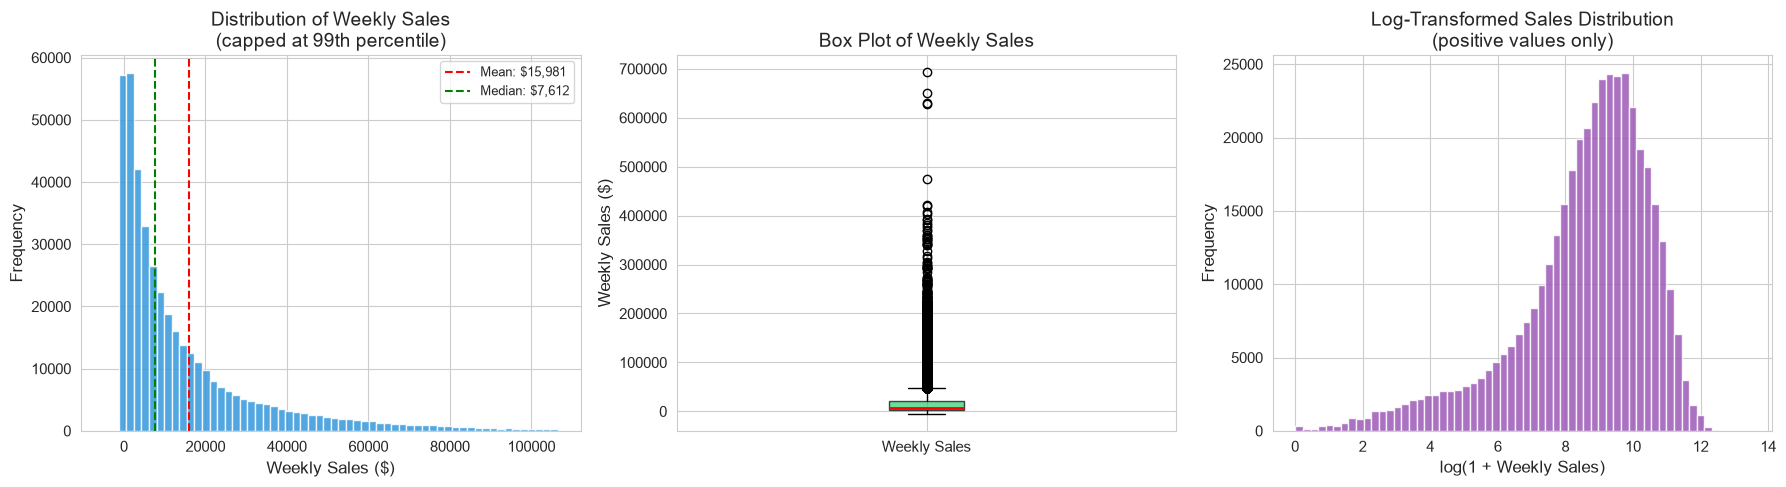

Observation: Sales distribution is heavily right-skewed (skewness = 3.26).
The median ($7,612) is much lower than the mean ($15,981), indicating a long right tail.
A few store-departments have very high sales (up to $693,099).


In [16]:
# ── Sales Distribution Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram (capped at 99th percentile for readability)
cap = sales.quantile(0.99)
axes[0].hist(sales[sales <= cap], bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(sales.mean(), color='red', linestyle='--', lw=1.5, label=f'Mean: ${sales.mean():,.0f}')
axes[0].axvline(sales.median(), color='green', linestyle='--', lw=1.5, label=f'Median: ${sales.median():,.0f}')
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Weekly Sales\n(capped at 99th percentile)')
axes[0].legend(fontsize=9)

# Box plot
bp = axes[1].boxplot(sales, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Weekly Sales ($)')
axes[1].set_title('Box Plot of Weekly Sales')
axes[1].set_xticklabels(['Weekly Sales'])

# Log-transformed histogram
positive_sales = sales[sales > 0]
axes[2].hist(np.log1p(positive_sales), bins=60, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('log(1 + Weekly Sales)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Log-Transformed Sales Distribution\n(positive values only)')

plt.tight_layout()
plt.show()

print("Observation: Sales distribution is heavily right-skewed (skewness = {:.2f}).".format(sales.skew()))
print("The median (${:,.0f}) is much lower than the mean (${:,.0f}), indicating a long right tail.".format(
    sales.median(), sales.mean()))
print("A few store-departments have very high sales (up to ${:,.0f}).".format(sales.max()))


---
## 8. Store-Wise Analysis

Analyze sales performance across the 45 Walmart stores.


In [17]:
# ── Store Sales Summary ───────────────────────────────────────────────────────
store_sales = df.groupby('Store')['Weekly_Sales'].agg(['sum', 'mean', 'median', 'std']).round(2)
store_sales.columns = ['Total_Sales', 'Avg_Sales', 'Median_Sales', 'Std_Sales']
store_sales = store_sales.sort_values('Total_Sales', ascending=False)

print("Top 5 Stores by Total Sales:")
for i, (store, row) in enumerate(store_sales.head().iterrows(), 1):
    print(f"  {i}. Store {store}: ${row['Total_Sales']:,.0f} (avg: ${row['Avg_Sales']:,.0f})")

print("\nBottom 5 Stores by Total Sales:")
for i, (store, row) in enumerate(store_sales.tail().iterrows(), 1):
    print(f"  {i}. Store {store}: ${row['Total_Sales']:,.0f} (avg: ${row['Avg_Sales']:,.0f})")


Top 5 Stores by Total Sales:
  1. Store 20: $301,397,792 (avg: $29,508)
  2. Store 4: $299,543,953 (avg: $29,161)
  3. Store 14: $288,999,911 (avg: $28,785)
  4. Store 13: $286,517,704 (avg: $27,355)
  5. Store 2: $275,382,441 (avg: $26,898)

Bottom 5 Stores by Total Sales:
  1. Store 38: $55,159,626 (avg: $7,492)
  2. Store 36: $53,412,215 (avg: $8,584)
  3. Store 5: $45,475,689 (avg: $5,053)
  4. Store 44: $43,293,088 (avg: $6,039)
  5. Store 33: $37,160,222 (avg: $5,728)


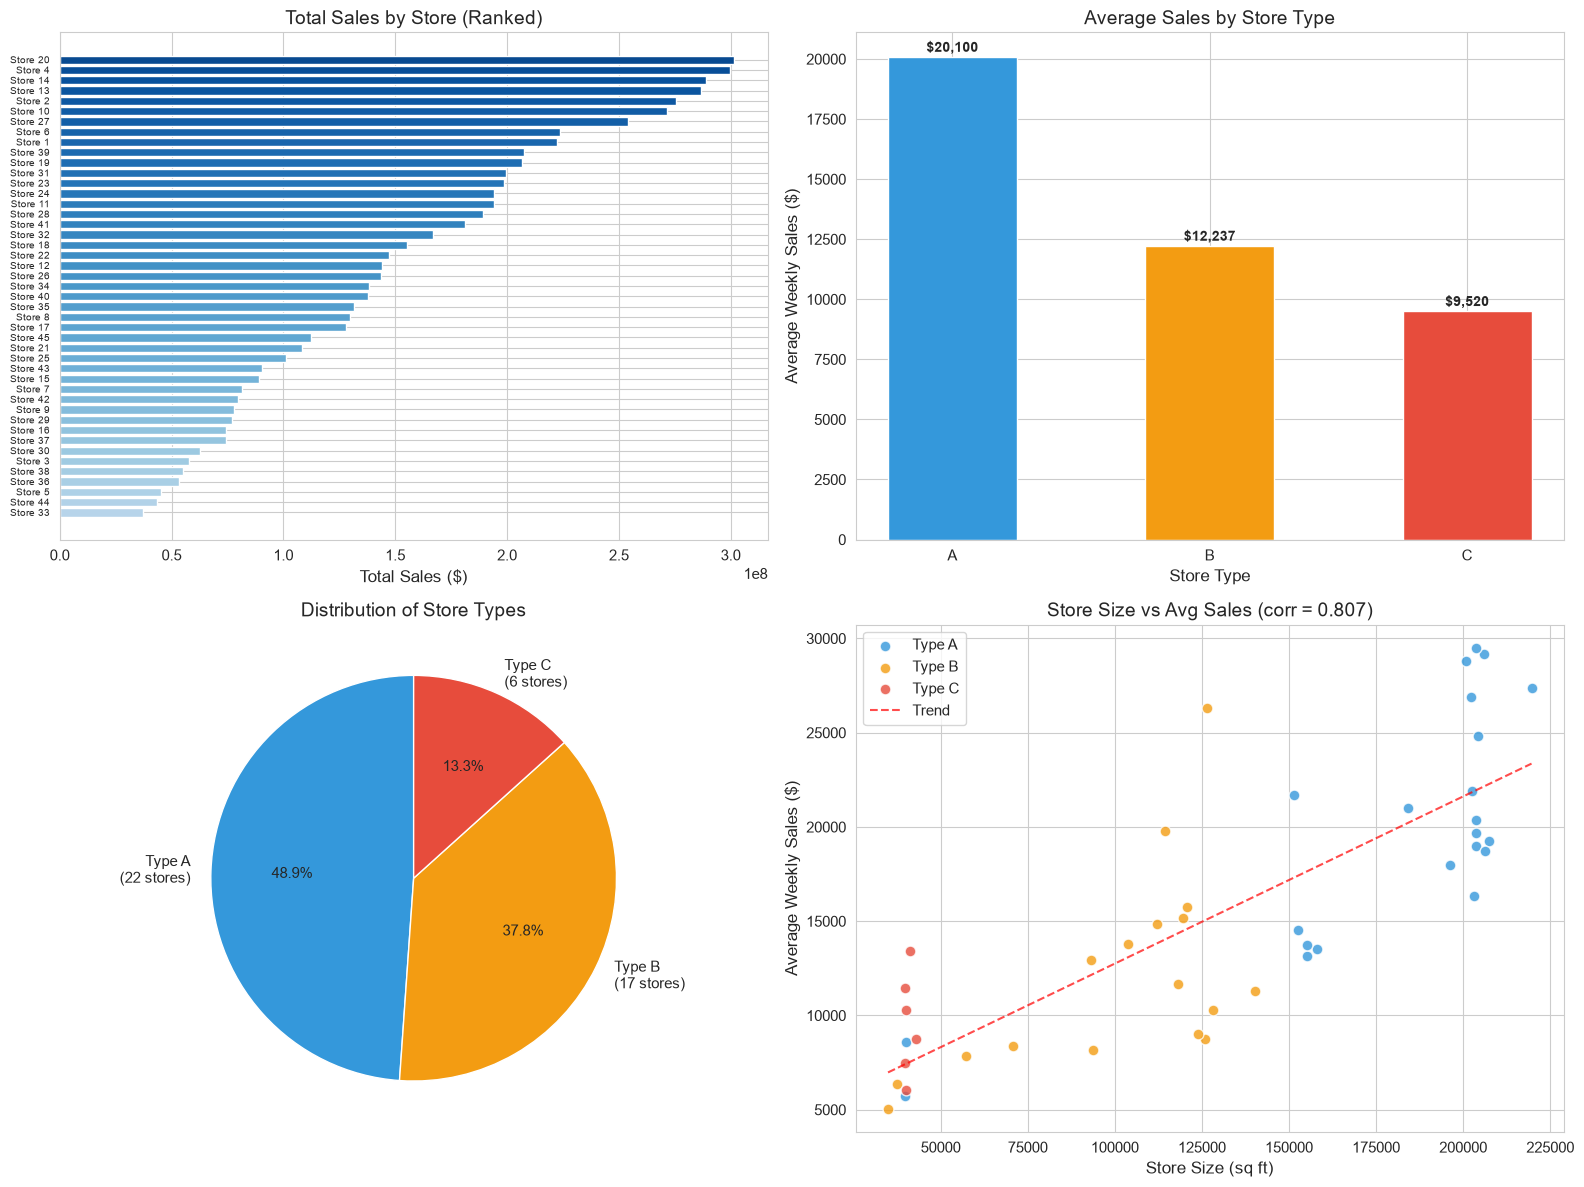

Observation: Type A stores (largest) have the highest average sales.
Store size shows a strong positive correlation (0.807) with average weekly sales.
Type C stores (smallest, only 6) consistently have the lowest sales.


In [18]:
# ── Store Sales Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total sales by store (sorted)
store_total = store_sales.reset_index()
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(store_total)))
axes[0, 0].barh(range(len(store_total)), store_total['Total_Sales'].values,
                color=colors[::-1])
axes[0, 0].set_yticks(range(len(store_total)))
axes[0, 0].set_yticklabels([f"Store {s}" for s in store_total['Store']], fontsize=7)
axes[0, 0].set_xlabel('Total Sales ($)')
axes[0, 0].set_title('Total Sales by Store (Ranked)')
axes[0, 0].invert_yaxis()

# 2. Average sales by store type
type_sales = df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)
type_colors = {'A': '#3498db', 'B': '#f39c12', 'C': '#e74c3c'}
axes[0, 1].bar(type_sales.index, type_sales.values,
               color=[type_colors[t] for t in type_sales.index],
               edgecolor='white', width=0.5)
axes[0, 1].set_xlabel('Store Type')
axes[0, 1].set_ylabel('Average Weekly Sales ($)')
axes[0, 1].set_title('Average Sales by Store Type')
for i, (t, v) in enumerate(type_sales.items()):
    axes[0, 1].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# 3. Store type distribution
type_counts = stores['Type'].value_counts()
axes[1, 0].pie(type_counts.values, labels=[f"Type {t}\n({c} stores)" for t, c in zip(type_counts.index, type_counts.values)],
               colors=[type_colors[t] for t in type_counts.index],
               autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1, 0].set_title('Distribution of Store Types')

# 4. Store size vs average sales
store_info = df.groupby('Store').agg({'Weekly_Sales': 'mean', 'Size': 'first', 'Type': 'first'}).reset_index()
for t, color in type_colors.items():
    mask = store_info['Type'] == t
    axes[1, 1].scatter(store_info[mask]['Size'], store_info[mask]['Weekly_Sales'],
                       c=color, s=60, alpha=0.8, label=f'Type {t}', edgecolors='white')
# Trend line
z = np.polyfit(store_info['Size'], store_info['Weekly_Sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(store_info['Size'].min(), store_info['Size'].max(), 100)
axes[1, 1].plot(x_line, p(x_line), 'r--', alpha=0.7, label='Trend')
corr = store_info['Size'].corr(store_info['Weekly_Sales'])
axes[1, 1].set_xlabel('Store Size (sq ft)')
axes[1, 1].set_ylabel('Average Weekly Sales ($)')
axes[1, 1].set_title(f'Store Size vs Avg Sales (corr = {corr:.3f})')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Observation: Type A stores (largest) have the highest average sales.")
print(f"Store size shows a strong positive correlation ({corr:.3f}) with average weekly sales.")
print(f"Type C stores (smallest, only 6) consistently have the lowest sales.")


---
## 9. Department-Wise Analysis

Analyze sales performance across departments.


In [19]:
# ── Department Sales ──────────────────────────────────────────────────────────
dept_sales = df.groupby('Dept')['Weekly_Sales'].agg(['sum', 'mean', 'std']).round(2)
dept_sales.columns = ['Total_Sales', 'Avg_Sales', 'Std_Sales']
dept_sales = dept_sales.sort_values('Total_Sales', ascending=False)

print(f"Total unique departments: {df['Dept'].nunique()}")
print(f"\nTop 10 Departments by Total Sales:")
for i, (dept, row) in enumerate(dept_sales.head(10).iterrows(), 1):
    print(f"  {i:>2}. Dept {dept:>2}: Total ${row['Total_Sales']:>15,.0f}  |  "
          f"Avg ${row['Avg_Sales']:>10,.0f}  |  Std ${row['Std_Sales']:>10,.0f}")


Total unique departments: 81

Top 10 Departments by Total Sales:
   1. Dept 92: Total $    483,943,342  |  Avg $    75,205  |  Std $    49,414
   2. Dept 95: Total $    449,320,163  |  Avg $    69,824  |  Std $    38,201
   3. Dept 38: Total $    393,118,137  |  Avg $    61,091  |  Std $    23,967
   4. Dept 72: Total $    305,725,152  |  Avg $    50,567  |  Std $    44,711
   5. Dept 90: Total $    291,068,464  |  Avg $    45,232  |  Std $    32,462
   6. Dept 40: Total $    288,936,022  |  Avg $    44,901  |  Std $    21,904
   7. Dept  2: Total $    280,611,174  |  Avg $    43,607  |  Std $    25,177
   8. Dept 91: Total $    216,781,706  |  Avg $    33,688  |  Std $    26,247
   9. Dept 13: Total $    197,321,570  |  Avg $    30,664  |  Std $    16,238
  10. Dept  8: Total $    194,280,781  |  Avg $    30,191  |  Std $    18,190


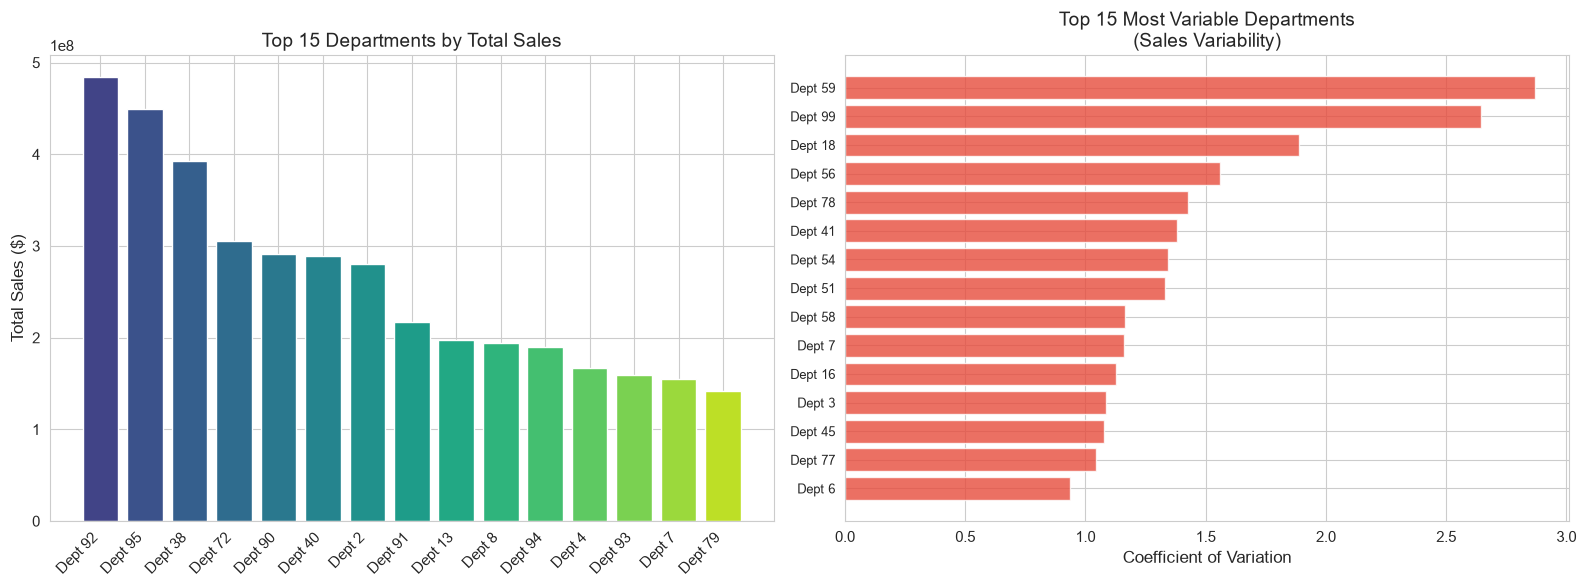

Observation: Department 92 dominates with $483,943,342 in total sales.
Some departments show very high variability, indicating seasonal or promotional sensitivity.


In [20]:
# ── Department Visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 departments
top15 = dept_sales.head(15).reset_index()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 15))
axes[0].bar(range(15), top15['Total_Sales'], color=colors, edgecolor='white')
axes[0].set_xticks(range(15))
axes[0].set_xticklabels([f"Dept {d}" for d in top15['Dept']], rotation=45, ha='right')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_title('Top 15 Departments by Total Sales')

# Department sales variability (coefficient of variation)
dept_cv = (dept_sales['Std_Sales'] / dept_sales['Avg_Sales']).sort_values(ascending=False).head(15)
dept_cv_df = dept_cv.reset_index()
axes[1].barh(range(15), dept_cv_df[0].values, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([f"Dept {d}" for d in dept_cv_df['Dept']], fontsize=9)
axes[1].set_xlabel('Coefficient of Variation')
axes[1].set_title('Top 15 Most Variable Departments\n(Sales Variability)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Observation: Department 92 dominates with ${dept_sales.iloc[0]['Total_Sales']:,.0f} in total sales.")
print(f"Some departments show very high variability, indicating seasonal or promotional sensitivity.")


---
## 10. Time-Series Analysis

Analyze how sales evolve over time to identify trends, seasonality, and patterns.


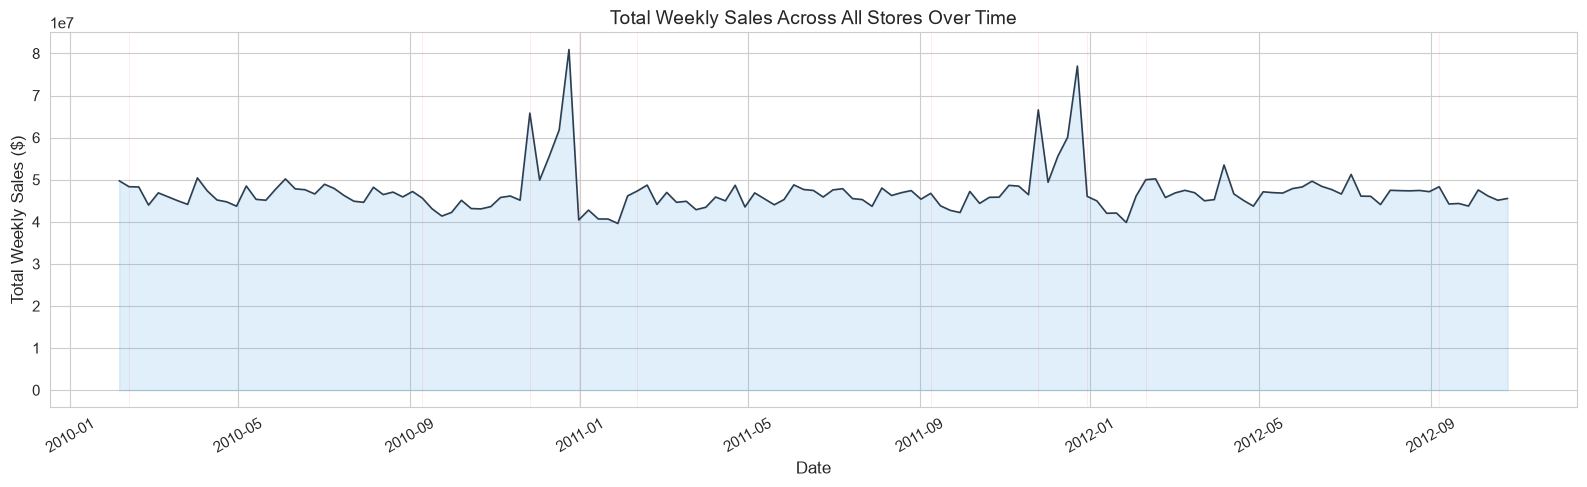

Observation: Clear yearly seasonality with major spikes around Thanksgiving/Christmas.
The red-shaded vertical lines indicate holiday weeks.


In [21]:
# ── Weekly Sales Trend ────────────────────────────────────────────────────────
weekly_total = df.groupby('Date')['Weekly_Sales'].sum().sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weekly_total.index, weekly_total.values, color='#2c3e50', linewidth=1.2)
ax.fill_between(weekly_total.index, weekly_total.values, alpha=0.15, color='#3498db')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales ($)')
ax.set_title('Total Weekly Sales Across All Stores Over Time')

# Mark holiday peaks
holiday_dates = df[df['IsHoliday'] == 1]['Date'].unique()
for hd in holiday_dates:
    if hd in weekly_total.index:
        ax.axvline(hd, color='red', alpha=0.1, linewidth=0.5)

ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print("Observation: Clear yearly seasonality with major spikes around Thanksgiving/Christmas.")
print("The red-shaded vertical lines indicate holiday weeks.")


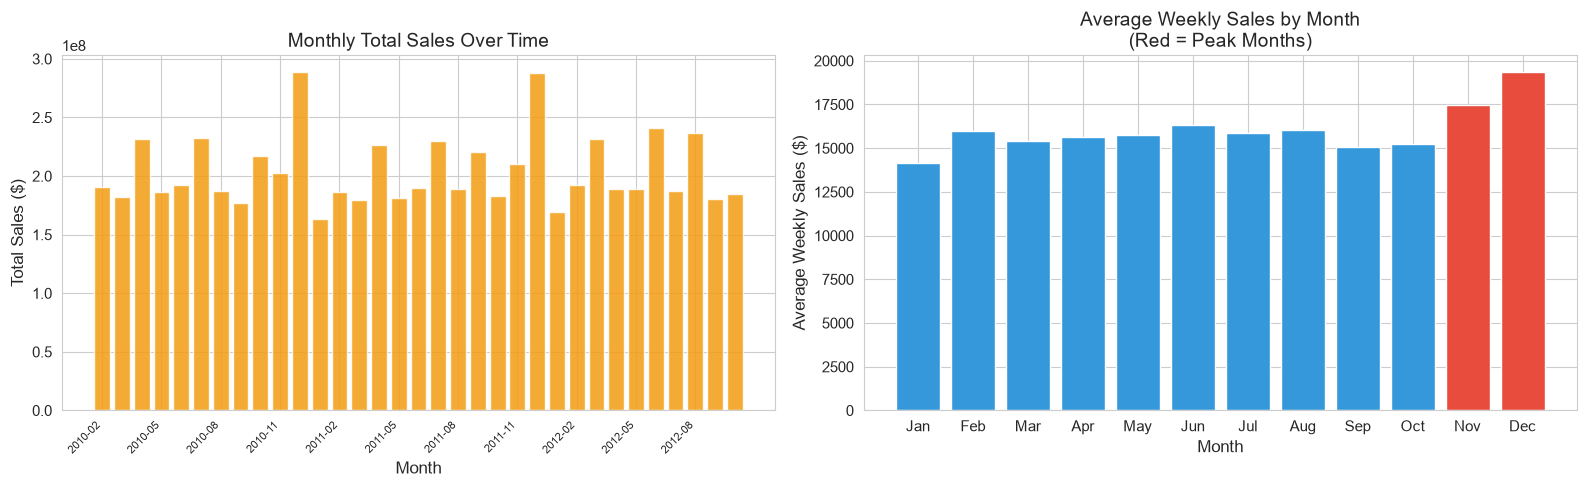

Observation: Sales peak in Dec (avg $19,356/week).
November and December are highlighted as peak months due to holiday shopping.


In [22]:
# ── Monthly Sales Pattern ─────────────────────────────────────────────────────
df_temp = df.copy()
df_temp['YearMonth'] = df_temp['Date'].dt.to_period('M')
monthly = df_temp.groupby('YearMonth')['Weekly_Sales'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly total sales over time
axes[0].bar(range(len(monthly)), monthly.values, color='#f39c12', edgecolor='white', alpha=0.85)
tick_pos = range(0, len(monthly), 3)
axes[0].set_xticks(list(tick_pos))
axes[0].set_xticklabels([str(monthly.index[i]) for i in tick_pos], rotation=45, ha='right', fontsize=8)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_title('Monthly Total Sales Over Time')

# Average sales by month (across all years)
month_avg = df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bar_colors = ['#e74c3c' if m in [11, 12] else '#3498db' for m in range(1, 13)]
axes[1].bar(range(1, 13), month_avg.values, color=bar_colors, edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Weekly Sales ($)')
axes[1].set_title('Average Weekly Sales by Month\n(Red = Peak Months)')

plt.tight_layout()
plt.show()

peak_month = month_avg.idxmax()
print(f"Observation: Sales peak in {month_names[peak_month-1]} (avg ${month_avg.max():,.0f}/week).")
print(f"November and December are highlighted as peak months due to holiday shopping.")


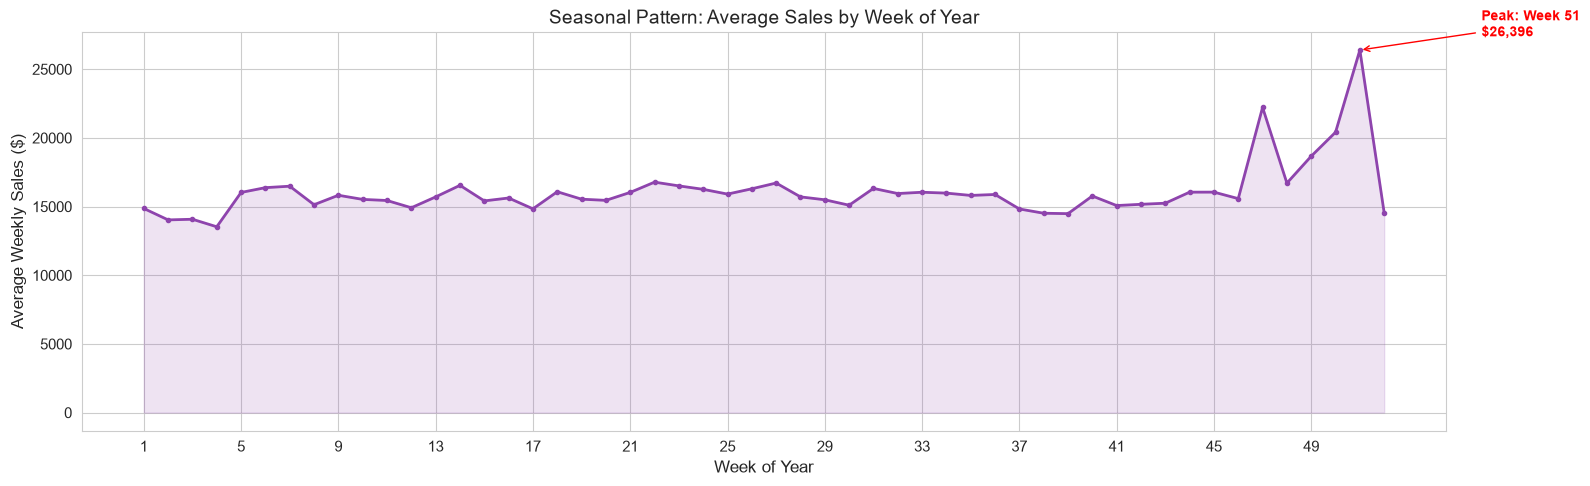

Observation: Week 51 has the highest average sales ($26,396).
This corresponds to the Thanksgiving/Black Friday period.
There's also a notable dip in January (post-holiday slowdown).


In [23]:
# ── Seasonal Pattern (Week of Year) ──────────────────────────────────────────
woy_avg = df.groupby('WeekOfYear')['Weekly_Sales'].mean().sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(woy_avg.index, woy_avg.values, color='#8e44ad', linewidth=2, marker='o', markersize=3)
ax.fill_between(woy_avg.index, woy_avg.values, alpha=0.15, color='#8e44ad')
ax.set_xlabel('Week of Year')
ax.set_ylabel('Average Weekly Sales ($)')
ax.set_title('Seasonal Pattern: Average Sales by Week of Year')
ax.set_xticks(range(1, 53, 4))

# Annotate the peak
peak_week = woy_avg.idxmax()
ax.annotate(f'Peak: Week {peak_week}\n${woy_avg.max():,.0f}',
            xy=(peak_week, woy_avg.max()),
            xytext=(peak_week + 5, woy_avg.max() + 1000),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Observation: Week {peak_week} has the highest average sales (${woy_avg.max():,.0f}).")
print("This corresponds to the Thanksgiving/Black Friday period.")
print("There's also a notable dip in January (post-holiday slowdown).")


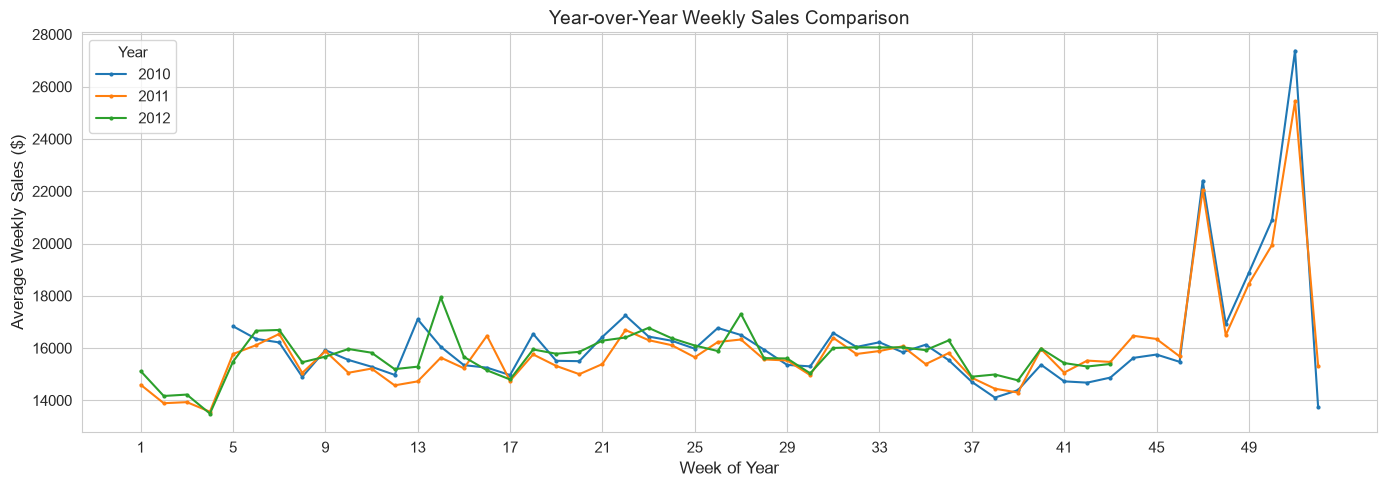

Observation: All three years show similar seasonal patterns,
confirming strong and consistent yearly seasonality in retail sales.


In [24]:
# ── Year-over-Year Comparison ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for year in sorted(df['Year'].unique()):
    yearly = df[df['Year'] == year].groupby('WeekOfYear')['Weekly_Sales'].mean().sort_index()
    ax.plot(yearly.index, yearly.values, linewidth=1.5, marker='o', markersize=2, label=str(year))

ax.set_xlabel('Week of Year')
ax.set_ylabel('Average Weekly Sales ($)')
ax.set_title('Year-over-Year Weekly Sales Comparison')
ax.legend(title='Year')
ax.set_xticks(range(1, 53, 4))
plt.tight_layout()
plt.show()

print("Observation: All three years show similar seasonal patterns,")
print("confirming strong and consistent yearly seasonality in retail sales.")


---
## 11. Holiday vs Non-Holiday Analysis

Compare sales during holiday and non-holiday weeks to quantify the holiday effect.


In [25]:
# ── Holiday Sales Comparison ──────────────────────────────────────────────────
hol_avg = df[df['IsHoliday'] == 1]['Weekly_Sales'].mean()
non_hol_avg = df[df['IsHoliday'] == 0]['Weekly_Sales'].mean()
hol_total = df[df['IsHoliday'] == 1]['Weekly_Sales'].sum()
non_hol_total = df[df['IsHoliday'] == 0]['Weekly_Sales'].sum()
pct_diff = ((hol_avg - non_hol_avg) / non_hol_avg) * 100

print("Holiday vs Non-Holiday Sales")
print("=" * 50)
print(f"  Holiday weeks:     Avg ${hol_avg:>12,.2f}  |  Count: {(df['IsHoliday'] == 1).sum():,}")
print(f"  Non-holiday weeks: Avg ${non_hol_avg:>12,.2f}  |  Count: {(df['IsHoliday'] == 0).sum():,}")
print(f"  Holiday premium:   {pct_diff:+.1f}%")


Holiday vs Non-Holiday Sales
  Holiday weeks:     Avg $   17,035.82  |  Count: 29,661
  Non-holiday weeks: Avg $   15,901.45  |  Count: 391,909
  Holiday premium:   +7.1%


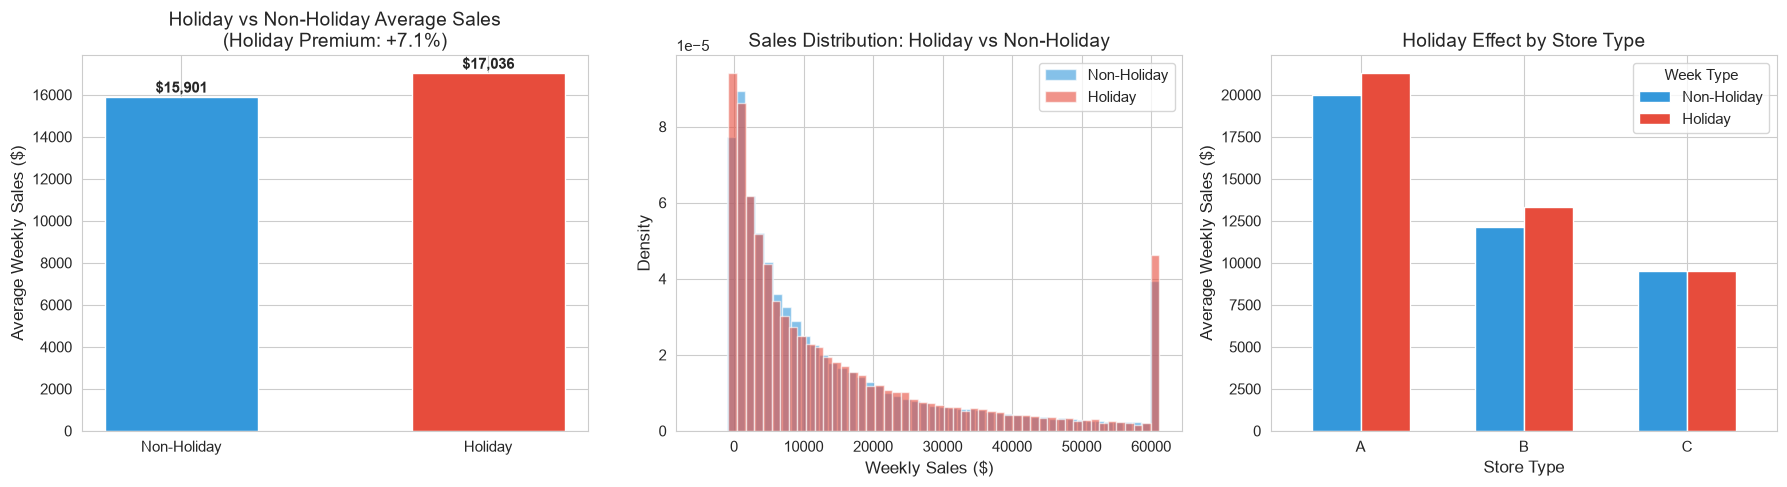

Observation: Holiday weeks show a consistent sales lift across all store types.
The effect is most pronounced in Type A stores (largest stores).


In [26]:
# ── Holiday Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Average sales comparison
bars = axes[0].bar(['Non-Holiday', 'Holiday'], [non_hol_avg, hol_avg],
                   color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_ylabel('Average Weekly Sales ($)')
axes[0].set_title(f'Holiday vs Non-Holiday Average Sales\n(Holiday Premium: {pct_diff:+.1f}%)')
for bar, val in zip(bars, [non_hol_avg, hol_avg]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

# 2. Sales distribution comparison
cap_val = df['Weekly_Sales'].quantile(0.95)
axes[1].hist(df[df['IsHoliday'] == 0]['Weekly_Sales'].clip(upper=cap_val),
             bins=50, alpha=0.6, color='#3498db', label='Non-Holiday', density=True)
axes[1].hist(df[df['IsHoliday'] == 1]['Weekly_Sales'].clip(upper=cap_val),
             bins=50, alpha=0.6, color='#e74c3c', label='Holiday', density=True)
axes[1].set_xlabel('Weekly Sales ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Sales Distribution: Holiday vs Non-Holiday')
axes[1].legend()

# 3. Holiday effect by store type
hol_by_type = df.pivot_table(values='Weekly_Sales', index='Type',
                              columns='IsHoliday', aggfunc='mean')
hol_by_type.columns = ['Non-Holiday', 'Holiday']
hol_by_type.plot(kind='bar', ax=axes[2], color=['#3498db', '#e74c3c'],
                 edgecolor='white', width=0.6)
axes[2].set_xlabel('Store Type')
axes[2].set_ylabel('Average Weekly Sales ($)')
axes[2].set_title('Holiday Effect by Store Type')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(title='Week Type')

plt.tight_layout()
plt.show()

print("Observation: Holiday weeks show a consistent sales lift across all store types.")
print("The effect is most pronounced in Type A stores (largest stores).")


---
## 12. Correlation Analysis

Examine relationships between numerical features and the target variable.


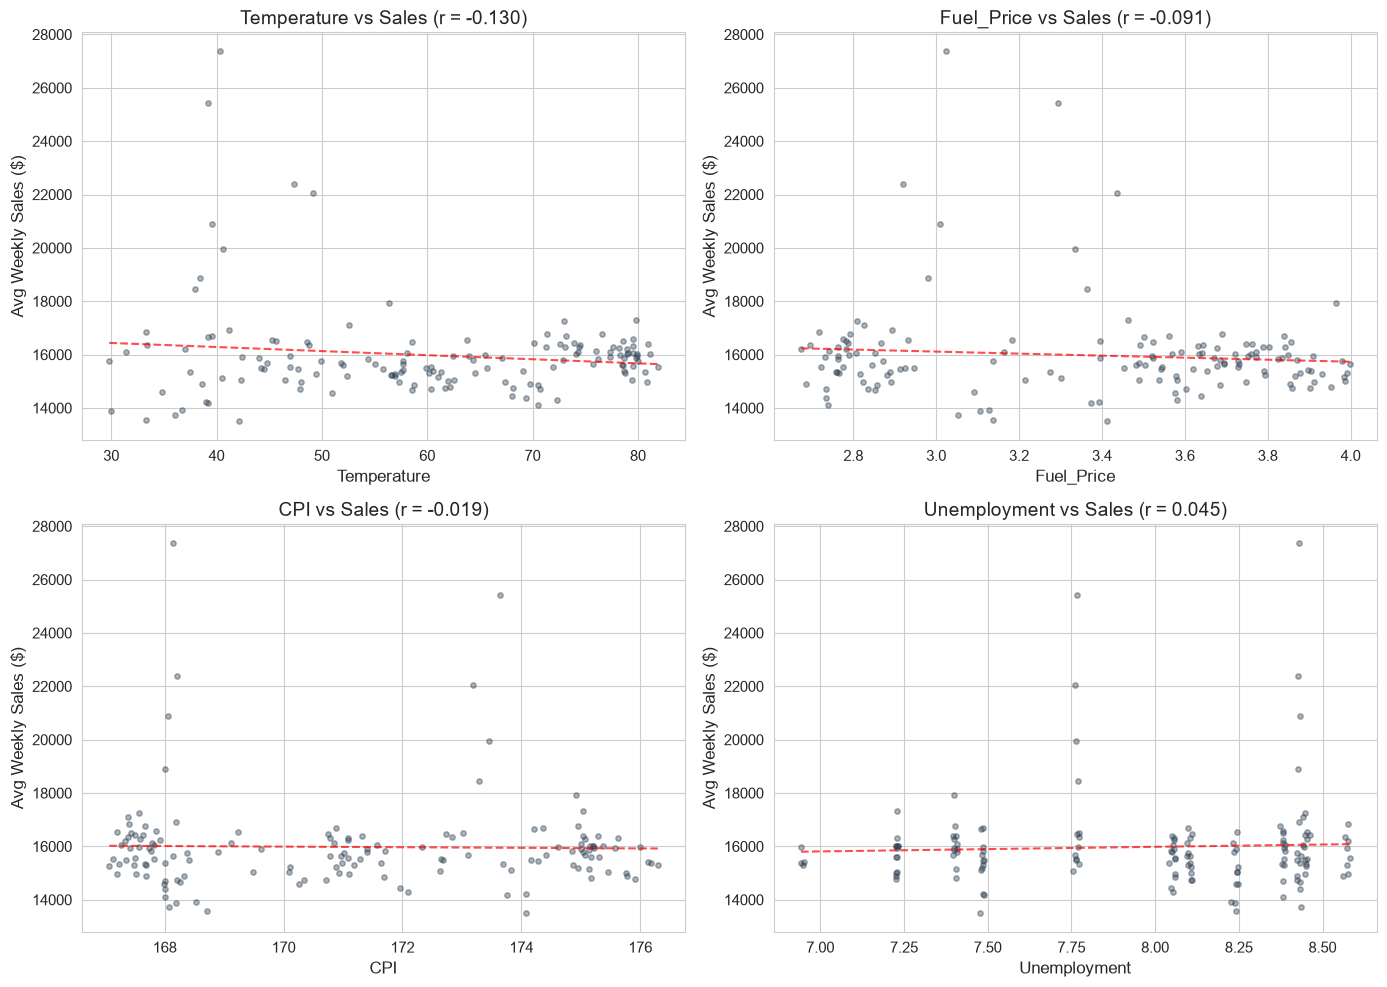

Observation: External factors show weak direct correlations with sales.
This suggests that store/department identity and seasonality are much
stronger predictors than macroeconomic indicators alone.


In [27]:
# ── External Factors vs Sales ─────────────────────────────────────────────────
ext_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(ext_cols):
    # Aggregate to weekly level for clearer patterns
    agg = df.groupby('Date').agg({'Weekly_Sales': 'mean', col: 'mean'}).reset_index()
    axes[i].scatter(agg[col], agg['Weekly_Sales'], alpha=0.4, s=15, color='#2c3e50')
    
    # Trend line
    z = np.polyfit(agg[col], agg['Weekly_Sales'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(agg[col])
    axes[i].plot(x_sorted, p(x_sorted), 'r--', alpha=0.7, linewidth=1.5)
    
    corr = agg[col].corr(agg['Weekly_Sales'])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Avg Weekly Sales ($)')
    axes[i].set_title(f'{col} vs Sales (r = {corr:.3f})')

plt.tight_layout()
plt.show()

print("Observation: External factors show weak direct correlations with sales.")
print("This suggests that store/department identity and seasonality are much")
print("stronger predictors than macroeconomic indicators alone.")


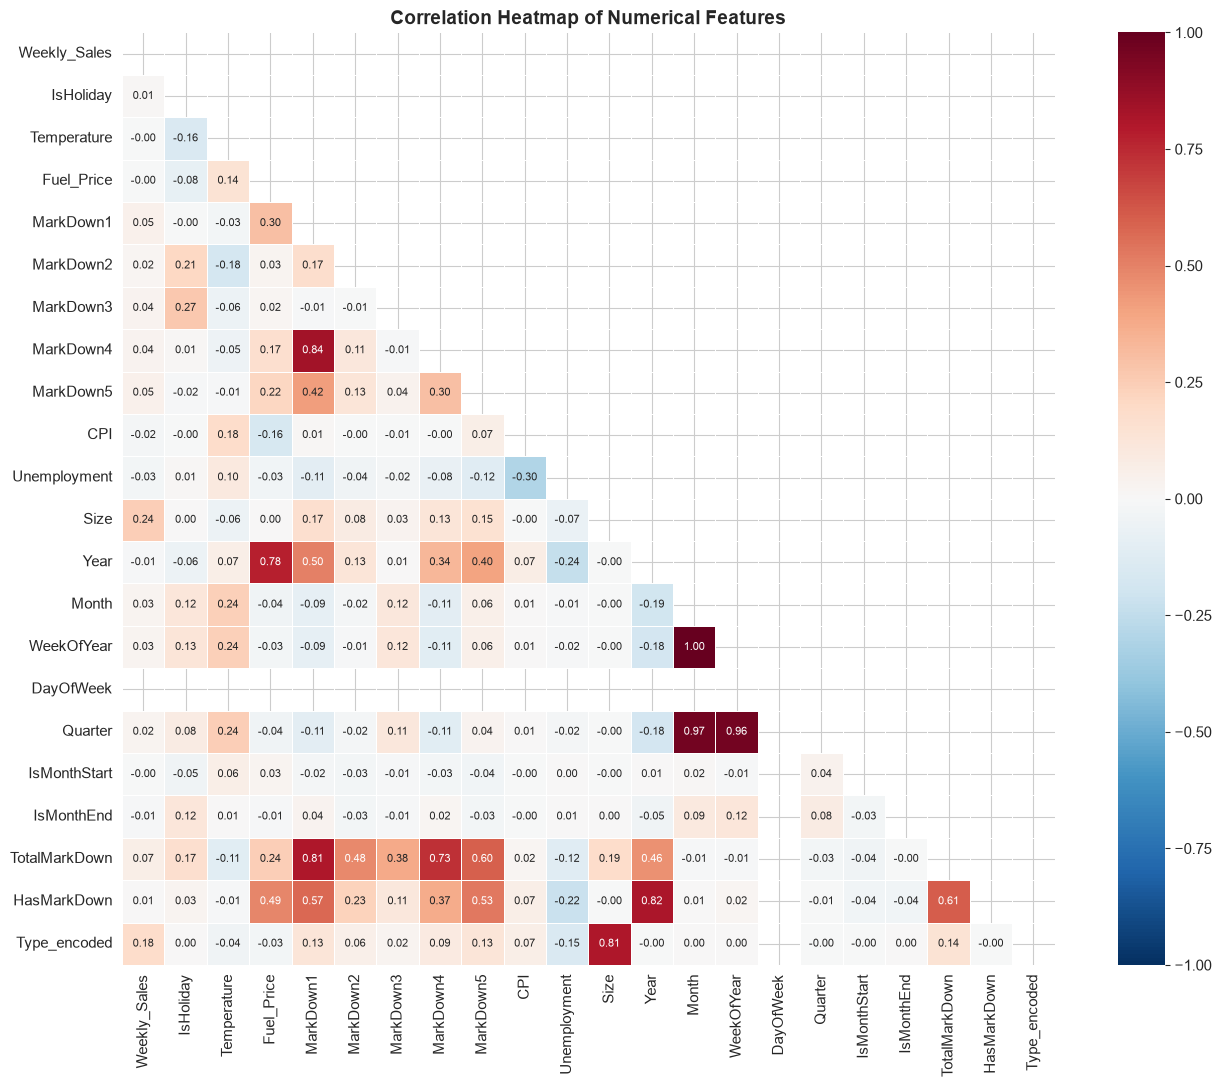

Top 10 features correlated with Weekly_Sales:
  Size                : +0.2438
  Type_encoded        : +0.1822
  TotalMarkDown       : +0.0652
  MarkDown5           : +0.0505
  MarkDown1           : +0.0472
  MarkDown3           : +0.0386
  MarkDown4           : +0.0375
  Month               : +0.0284
  WeekOfYear          : +0.0277
  Unemployment        : -0.0259


In [28]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude identifier columns
corr_cols = [c for c in numeric_cols if c not in ['Store', 'Dept']]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with target
target_corr = corr_matrix['Weekly_Sales'].drop('Weekly_Sales').abs().sort_values(ascending=False)
print("Top 10 features correlated with Weekly_Sales:")
for feat, corr_val in target_corr.head(10).items():
    sign = "+" if corr_matrix.loc[feat, 'Weekly_Sales'] > 0 else "-"
    print(f"  {feat:20s}: {sign}{corr_val:.4f}")


---
## 13. Markdown & Promotional Impact

Analyze the relationship between promotional markdowns and sales.


Markdown Impact Analysis
  With markdowns:    $16,177.02 avg  (151,432 records)
  Without markdowns: $15,871.52 avg  (270,138 records)
  Markdown effect:   +1.9%


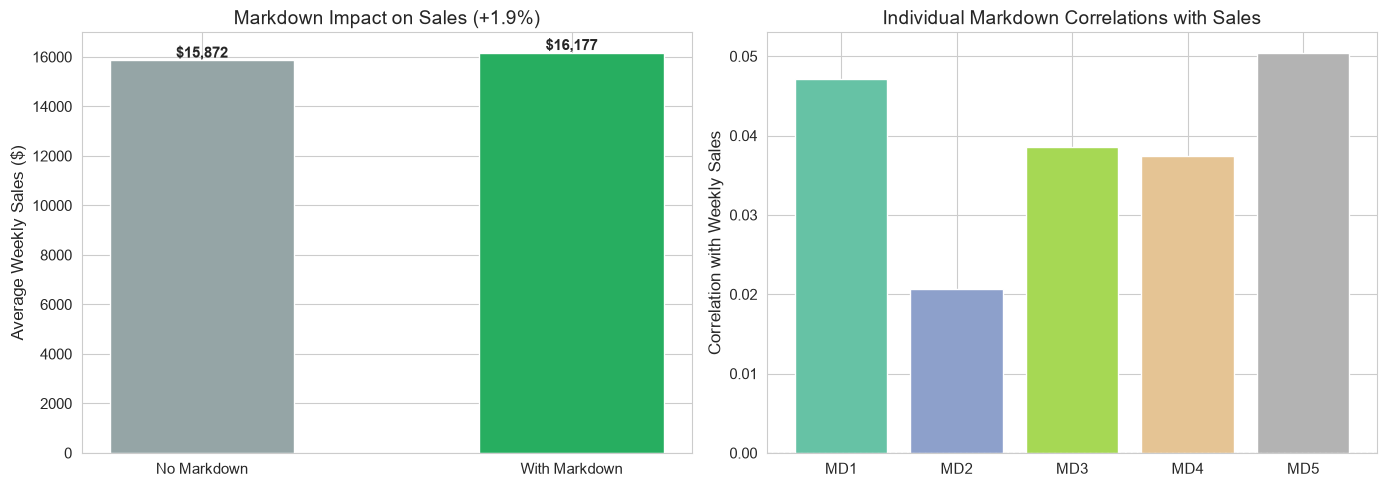


Note: Markdown columns represent promotional discounts.
The modest effect suggests markdowns may shift purchase timing
rather than creating substantial new demand.


In [29]:
# ── Markdown Impact ───────────────────────────────────────────────────────────
has_md = df['TotalMarkDown'] > 0
md_sales_avg = df[has_md]['Weekly_Sales'].mean()
no_md_sales_avg = df[~has_md]['Weekly_Sales'].mean()
md_pct = ((md_sales_avg - no_md_sales_avg) / no_md_sales_avg) * 100

print("Markdown Impact Analysis")
print("=" * 50)
print(f"  With markdowns:    ${md_sales_avg:,.2f} avg  ({has_md.sum():,} records)")
print(f"  Without markdowns: ${no_md_sales_avg:,.2f} avg  ({(~has_md).sum():,} records)")
print(f"  Markdown effect:   {md_pct:+.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Impact bar chart
bars = axes[0].bar(['No Markdown', 'With Markdown'],
                   [no_md_sales_avg, md_sales_avg],
                   color=['#95a5a6', '#27ae60'], edgecolor='white', width=0.5)
axes[0].set_ylabel('Average Weekly Sales ($)')
axes[0].set_title(f'Markdown Impact on Sales ({md_pct:+.1f}%)')
for bar, val in zip(bars, [no_md_sales_avg, md_sales_avg]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'${val:,.0f}', ha='center', fontweight='bold')

# Individual markdown correlations
md_corrs = [df[col].corr(df['Weekly_Sales']) for col in md_cols]
axes[1].bar(range(5), md_corrs, color=plt.cm.Set2(np.linspace(0, 1, 5)), edgecolor='white')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([f'MD{i+1}' for i in range(5)])
axes[1].set_ylabel('Correlation with Weekly Sales')
axes[1].set_title('Individual Markdown Correlations with Sales')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print("\nNote: Markdown columns represent promotional discounts.")
print("The modest effect suggests markdowns may shift purchase timing")
print("rather than creating substantial new demand.")


---
## 14. Machine Learning - Model Training

### Time-Based Validation Strategy

Because this is a **sales forecasting** problem, we use **time-based validation** instead of random splitting:
- **Training**: All data before July 2012 (~85%)
- **Validation**: Data from July 2012 onward (~15%)

This prevents data leakage and mimics real-world forecasting where we predict future sales from past data.

### Models to Compare
1. **Naive Mean Baseline** -- mean sales per (Store, Dept) from training
2. **Linear Regression** -- simple linear model with feature scaling
3. **Random Forest** -- ensemble of decision trees
4. **Gradient Boosting (HistGBR)** -- sequential boosting with histogram binning


In [30]:
# ── Prepare Features ──────────────────────────────────────────────────────────
feature_cols = [
    'Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment', 'Size', 'Type_encoded',
    'Year', 'Month', 'WeekOfYear', 'DayOfWeek', 'Quarter',
    'IsMonthStart', 'IsMonthEnd', 'TotalMarkDown', 'HasMarkDown'
]

X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()
date_series = df['Date'].copy()

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Target: Weekly_Sales (mean={y.mean():,.2f}, std={y.std():,.2f})")
print(f"\nFeature columns:\n  {feature_cols}")


Feature matrix: 421,570 rows x 23 features
Target: Weekly_Sales (mean=15,981.26, std=22,711.18)

Feature columns:
  ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Type_encoded', 'Year', 'Month', 'WeekOfYear', 'DayOfWeek', 'Quarter', 'IsMonthStart', 'IsMonthEnd', 'TotalMarkDown', 'HasMarkDown']


In [31]:
# ── Time-Based Split ──────────────────────────────────────────────────────────
SPLIT_DATE = '2012-07-01'
split_dt = pd.to_datetime(SPLIT_DATE)

train_mask = date_series < split_dt
val_mask = date_series >= split_dt

X_train, X_val = X[train_mask], X[val_mask]
y_train, y_val = y[train_mask], y[val_mask]

print(f"Time-based split at {SPLIT_DATE}:")
print(f"  Training:   {X_train.shape[0]:,} rows ({date_series[train_mask].min().date()} -> {date_series[train_mask].max().date()})")
print(f"  Validation: {X_val.shape[0]:,} rows ({date_series[val_mask].min().date()} -> {date_series[val_mask].max().date()})")
print(f"  Split ratio: {X_train.shape[0]/len(X)*100:.1f}% / {X_val.shape[0]/len(X)*100:.1f}%")


Time-based split at 2012-07-01:
  Training:   371,242 rows (2010-02-05 -> 2012-06-29)
  Validation: 50,328 rows (2012-07-06 -> 2012-10-26)
  Split ratio: 88.1% / 11.9%


In [32]:
# ── Model 1: Naive Mean Baseline ──────────────────────────────────────────────
print("Training Naive Mean Baseline...")
train_df_temp = X_train[['Store', 'Dept']].copy()
train_df_temp['Weekly_Sales'] = y_train.values
store_dept_means = train_df_temp.groupby(['Store', 'Dept'])['Weekly_Sales'].mean().to_dict()
global_mean = y_train.mean()

def predict_baseline(X_input):
    return np.array([
        store_dept_means.get((row['Store'], row['Dept']), global_mean)
        for _, row in X_input[['Store', 'Dept']].iterrows()
    ])

baseline_preds_val = predict_baseline(X_val)
print("  Done.")


Training Naive Mean Baseline...
  Done.


In [33]:
# ── Model 2: Linear Regression ────────────────────────────────────────────────
print("Training Linear Regression...")
scaler = StandardScaler()
non_id_cols = [c for c in feature_cols if c not in ['Store', 'Dept']]

X_train_scaled = X_train.copy()
X_train_scaled[non_id_cols] = scaler.fit_transform(X_train[non_id_cols])

X_val_scaled = X_val.copy()
X_val_scaled[non_id_cols] = scaler.transform(X_val[non_id_cols])

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds_val = lr_model.predict(X_val_scaled)
print("  Done.")


Training Linear Regression...
  Done.


In [34]:
# ── Model 3: Random Forest ────────────────────────────────────────────────────
print("Training Random Forest (this may take a minute)...")
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_leaf=5,
    n_jobs=-1, random_state=42
)
rf_model.fit(X_train, y_train)
rf_preds_val = rf_model.predict(X_val)
print("  Done.")


Training Random Forest (this may take a minute)...
  Done.


In [35]:
# ── Model 4: Gradient Boosting (HistGBR) ─────────────────────────────────────
print("Training Gradient Boosting (HistGradientBoostingRegressor)...")
hgb_model = HistGradientBoostingRegressor(
    max_iter=200, max_depth=6, learning_rate=0.1, random_state=42
)
hgb_model.fit(X_train, y_train)
hgb_preds_val = hgb_model.predict(X_val)
print("  Done.")
print("\nAll 4 models trained successfully!")


Training Gradient Boosting (HistGradientBoostingRegressor)...
  Done.

All 4 models trained successfully!


---
## 15. Model Comparison

Evaluate all models on the **validation set** (future data the models haven't seen).

### Metrics Used
| Metric | Meaning |
|--------|---------|
| **MAE** | Average dollar error per prediction |
| **RMSE** | Penalizes large errors more heavily |
| **R-squared** | Proportion of variance explained (0-1) |
| **MAPE** | Percentage error (rows with \|actual\| < $100 excluded) |


In [36]:
# ── Evaluation Functions ──────────────────────────────────────────────────────
def compute_mape(y_true, y_pred, threshold=100):
    """MAPE excluding near-zero actuals to avoid division issues."""
    y_t = np.array(y_true)
    y_p = np.array(y_pred)
    mask = np.abs(y_t) >= threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_t[mask] - y_p[mask]) / y_t[mask])) * 100

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = compute_mape(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'R2': round(r2, 4), 'MAPE': round(mape, 2)}

# ── Compute Metrics ──────────────────────────────────────────────────────────
results = []
results.append(evaluate_model('Naive Mean Baseline', y_val, baseline_preds_val))
results.append(evaluate_model('Linear Regression', y_val, lr_preds_val))
results.append(evaluate_model('Random Forest', y_val, rf_preds_val))
results.append(evaluate_model('Gradient Boosting', y_val, hgb_preds_val))

comparison_df = pd.DataFrame(results)
print("\n" + "=" * 75)
print("MODEL COMPARISON (Validation Set)")
print("=" * 75)
print(comparison_df.to_string(index=False))
print("=" * 75)



MODEL COMPARISON (Validation Set)
              Model      MAE     RMSE     R2   MAPE
Naive Mean Baseline  2495.09  5080.62 0.9465  39.77
  Linear Regression 14639.81 20963.37 0.0893 711.36
      Random Forest  2075.79  4005.37 0.9668  29.84
  Gradient Boosting  3516.35  5859.75 0.9288 105.55


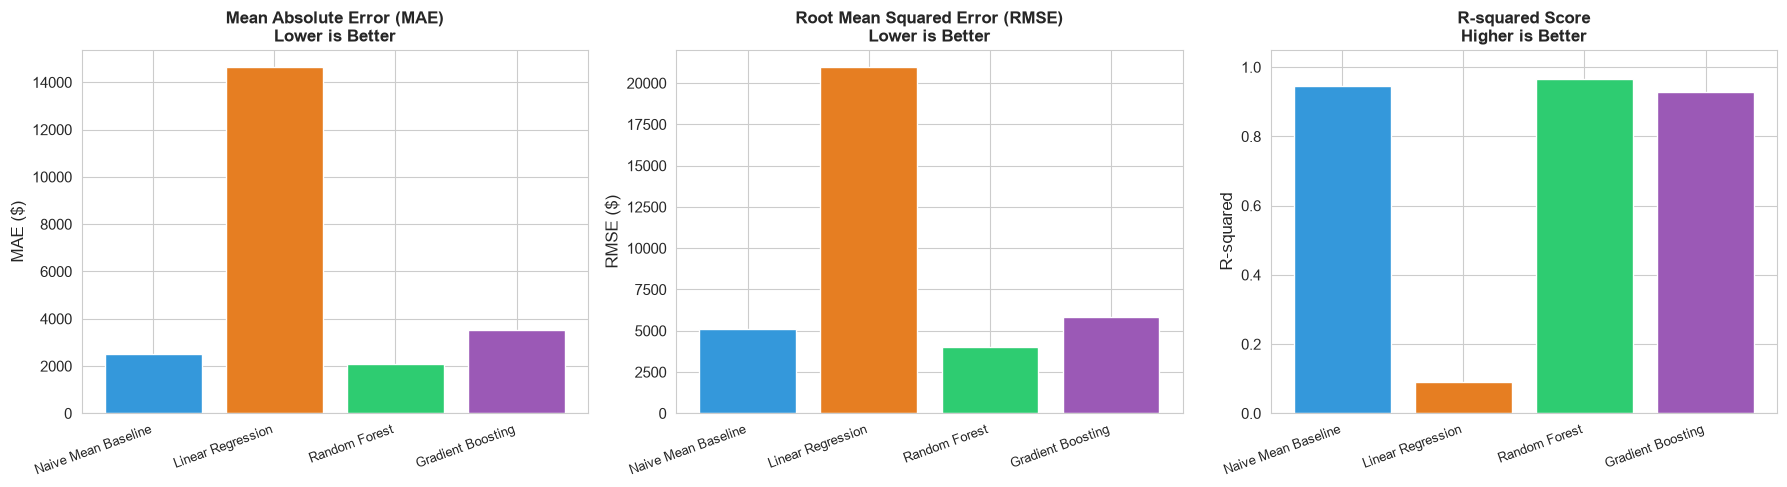


Best model by RMSE: Random Forest
  MAE:  $2,075.79
  RMSE: $4,005.37
  R2:   0.9668
  MAPE: 29.84%


In [37]:
# ── Model Comparison Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_list = comparison_df['Model'].tolist()
x = range(len(models_list))
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

# MAE
axes[0].bar(x, comparison_df['MAE'].values, color=colors, edgecolor='white')
axes[0].set_title('Mean Absolute Error (MAE)\nLower is Better', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE ($)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list, rotation=20, ha='right', fontsize=9)

# RMSE
axes[1].bar(x, comparison_df['RMSE'].values, color=colors, edgecolor='white')
axes[1].set_title('Root Mean Squared Error (RMSE)\nLower is Better', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_list, rotation=20, ha='right', fontsize=9)

# R-squared
axes[2].bar(x, comparison_df['R2'].values, color=colors, edgecolor='white')
axes[2].set_title('R-squared Score\nHigher is Better', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R-squared')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models_list, rotation=20, ha='right', fontsize=9)
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Identify best model
best_idx = comparison_df['RMSE'].idxmin()
best_model_name = comparison_df.loc[best_idx, 'Model']
print(f"\nBest model by RMSE: {best_model_name}")
print(f"  MAE:  ${comparison_df.loc[best_idx, 'MAE']:,.2f}")
print(f"  RMSE: ${comparison_df.loc[best_idx, 'RMSE']:,.2f}")
print(f"  R2:   {comparison_df.loc[best_idx, 'R2']}")
print(f"  MAPE: {comparison_df.loc[best_idx, 'MAPE']}%")


### Model Selection Analysis

The model with the **lowest RMSE** on the validation set is selected as the final model. RMSE is chosen as the primary metric because:
- It penalizes large errors more heavily than MAE
- Large prediction errors (e.g., off by $50K) are much worse than many small ones in retail planning
- It's expressed in the same units as the target ($), making it interpretable

**Linear Regression** performed poorly because the relationships between features and sales are highly non-linear (stores and departments have vastly different baseline sales levels that a linear model cannot capture well).

The **Naive Mean Baseline** was surprisingly competitive, confirming that store-department identity is the single strongest predictor of sales.


---
## 16. Final Model Evaluation

Detailed evaluation of the best-performing model.


In [38]:
# ── Select Best Model's Predictions ──────────────────────────────────────────
# Map model names to their predictions
preds_map = {
    'Naive Mean Baseline': baseline_preds_val,
    'Linear Regression': lr_preds_val,
    'Random Forest': rf_preds_val,
    'Gradient Boosting': hgb_preds_val,
}

best_preds = preds_map[best_model_name]
y_val_arr = np.array(y_val)

print(f"Final Model: {best_model_name}")
print(f"Validation samples: {len(y_val):,}")


Final Model: Random Forest
Validation samples: 50,328


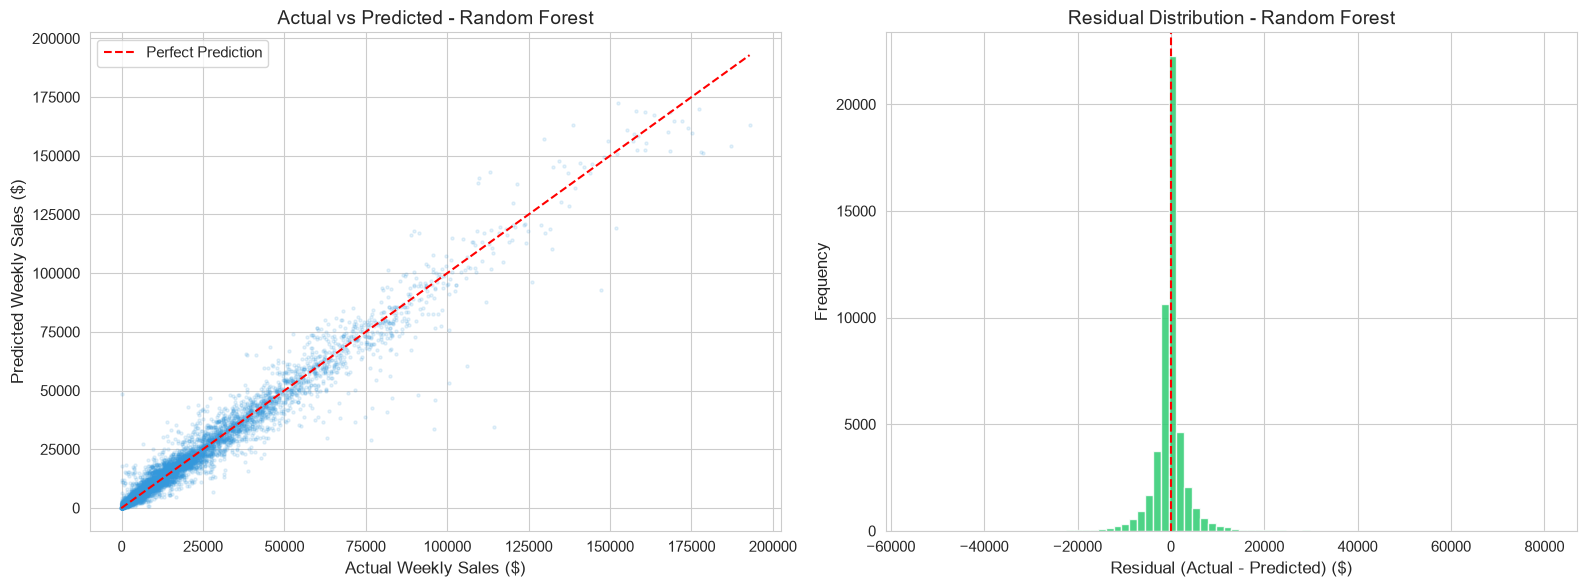

Residual Statistics:
  Mean:   $   -203.15  (should be near 0)
  Std:    $  4,000.22
  Median: $   -103.19
  Min:    $-54,348.51
  Max:    $ 80,249.92


In [39]:
# ── Actual vs Predicted ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot (sample for performance)
n = len(y_val_arr)
if n > 10000:
    idx = np.random.RandomState(42).choice(n, 10000, replace=False)
    y_true_s, y_pred_s = y_val_arr[idx], best_preds[idx]
else:
    y_true_s, y_pred_s = y_val_arr, best_preds

axes[0].scatter(y_true_s, y_pred_s, alpha=0.12, s=5, color='#3498db')
lim_min = min(y_true_s.min(), y_pred_s.min())
lim_max = max(y_true_s.max(), y_pred_s.max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Weekly Sales ($)')
axes[0].set_ylabel('Predicted Weekly Sales ($)')
axes[0].set_title(f'Actual vs Predicted - {best_model_name}')
axes[0].legend()

# Residual distribution
residuals = y_val_arr - best_preds
axes[1].hist(residuals, bins=80, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted) ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution - {best_model_name}')

plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"  Mean:   ${residuals.mean():>10,.2f}  (should be near 0)")
print(f"  Std:    ${residuals.std():>10,.2f}")
print(f"  Median: ${np.median(residuals):>10,.2f}")
print(f"  Min:    ${residuals.min():>10,.2f}")
print(f"  Max:    ${residuals.max():>10,.2f}")


---
## 17. Feature Importance

Identify which features have the strongest influence on sales predictions.

> **Important**: Feature importance indicates *predictive value*, not *causal relationship*.
> A feature being important for prediction does not prove it directly causes sales changes.


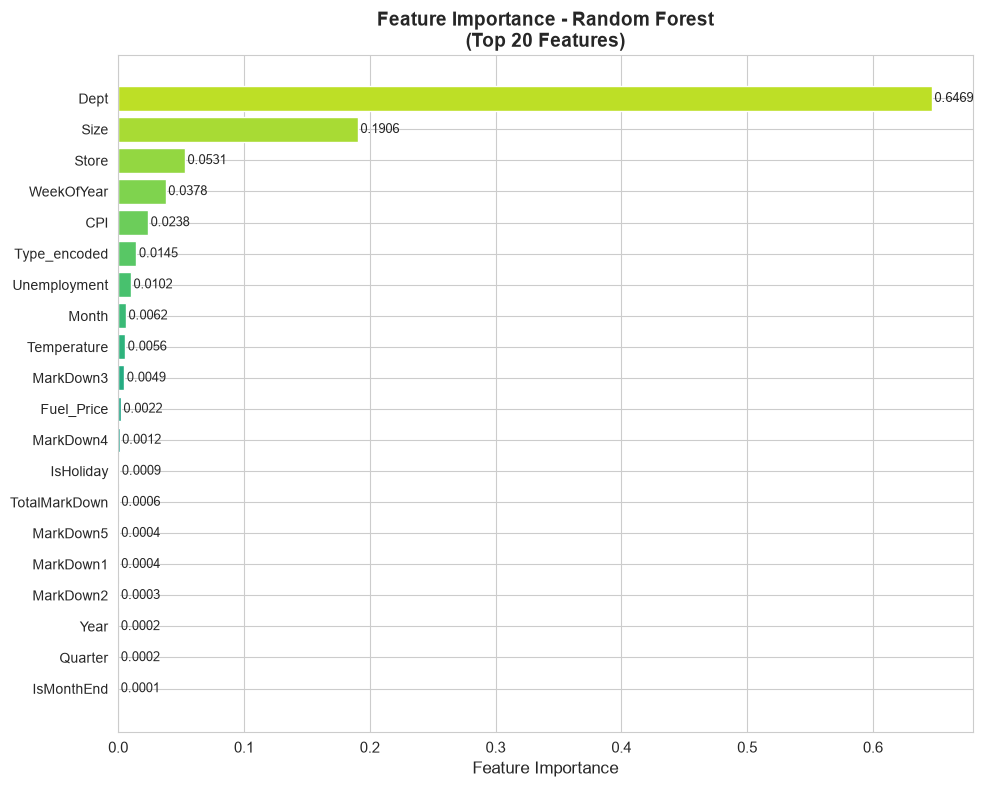

Top 10 Most Important Features:
   1. Dept                : 0.6469 (64.7%)
   2. Size                : 0.1906 (19.1%)
   3. Store               : 0.0531 (5.3%)
   4. WeekOfYear          : 0.0378 (3.8%)
   5. CPI                 : 0.0238 (2.4%)
   6. Type_encoded        : 0.0145 (1.5%)
   7. Unemployment        : 0.0102 (1.0%)
   8. Month               : 0.0062 (0.6%)
   9. Temperature         : 0.0056 (0.6%)
  10. MarkDown3           : 0.0049 (0.5%)

Note: Feature importance shows predictive value, NOT causal effect.
Dept and Store being dominant means the model primarily learns per-store-department patterns.


In [40]:
# ── Feature Importance (from the best tree-based model) ──────────────────────
# Use Random Forest importance (always available and stable)
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(feat_imp))
top_feats = feat_imp.head(top_n)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax.barh(range(top_n), top_feats['Importance'].values[::-1], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats['Feature'].values[::-1], fontsize=10)
ax.set_xlabel('Feature Importance')
ax.set_title(f'Feature Importance - Random Forest\n(Top {top_n} Features)', fontsize=14, fontweight='bold')

# Annotate values
for i, (val, name) in enumerate(zip(top_feats['Importance'].values[::-1], top_feats['Feature'].values[::-1])):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
for i, (_, row) in enumerate(feat_imp.head(10).iterrows(), 1):
    print(f"  {i:>2}. {row['Feature']:20s}: {row['Importance']:.4f} ({row['Importance']*100:.1f}%)")

print("\nNote: Feature importance shows predictive value, NOT causal effect.")
print("Dept and Store being dominant means the model primarily learns per-store-department patterns.")


---
## 18. Prediction Examples

Demonstrate the prediction pipeline with sample inputs.


In [41]:
# ── Prediction Function ───────────────────────────────────────────────────────
def make_prediction(store, dept, date_str, is_holiday, temperature, fuel_price,
                    cpi, unemployment, md1=0, md2=0, md3=0, md4=0, md5=0):
    """Make a single prediction using the Random Forest model."""
    date = pd.to_datetime(date_str)
    
    # Get store info
    store_row = stores[stores['Store'] == store]
    if len(store_row) > 0:
        type_enc = type_map.get(store_row.iloc[0]['Type'], 1)
        size = store_row.iloc[0]['Size']
    else:
        type_enc, size = 1, 130000
    
    input_data = pd.DataFrame([{
        'Store': store, 'Dept': dept, 'IsHoliday': int(is_holiday),
        'Temperature': temperature, 'Fuel_Price': fuel_price,
        'MarkDown1': md1, 'MarkDown2': md2, 'MarkDown3': md3,
        'MarkDown4': md4, 'MarkDown5': md5,
        'CPI': cpi, 'Unemployment': unemployment,
        'Size': size, 'Type_encoded': type_enc,
        'Year': date.year, 'Month': date.month,
        'WeekOfYear': date.isocalendar().week,
        'DayOfWeek': date.dayofweek, 'Quarter': date.quarter,
        'IsMonthStart': int(date.is_month_start),
        'IsMonthEnd': int(date.is_month_end),
        'TotalMarkDown': md1 + md2 + md3 + md4 + md5,
        'HasMarkDown': int((md1 + md2 + md3 + md4 + md5) > 0),
    }])
    
    return rf_model.predict(input_data[feature_cols])[0]

# ── Sample Predictions ───────────────────────────────────────────────────────
examples = [
    {'store': 1, 'dept': 1, 'date': '2013-01-04', 'is_holiday': False,
     'temp': 40.0, 'fuel': 3.50, 'cpi': 220.0, 'unemp': 6.5},
    {'store': 20, 'dept': 92, 'date': '2013-03-15', 'is_holiday': False,
     'temp': 55.0, 'fuel': 3.60, 'cpi': 225.0, 'unemp': 6.0},
    {'store': 4, 'dept': 72, 'date': '2012-11-23', 'is_holiday': True,
     'temp': 35.0, 'fuel': 3.40, 'cpi': 218.0, 'unemp': 7.0},
    {'store': 33, 'dept': 5, 'date': '2013-06-01', 'is_holiday': False,
     'temp': 80.0, 'fuel': 3.70, 'cpi': 222.0, 'unemp': 5.8},
]

print("Sample Predictions")
print("=" * 80)
for ex in examples:
    pred = make_prediction(ex['store'], ex['dept'], ex['date'], ex['is_holiday'],
                           ex['temp'], ex['fuel'], ex['cpi'], ex['unemp'])
    # Get historical context
    hist = df[(df['Store'] == ex['store']) & (df['Dept'] == ex['dept'])]['Weekly_Sales']
    hist_avg = hist.mean() if len(hist) > 0 else 0
    print(f"  Store {ex['store']:>2}, Dept {ex['dept']:>2}, {ex['date']}, "
          f"Holiday={'Yes' if ex['is_holiday'] else 'No':>3}: "
          f"  Predicted: ${pred:>12,.2f}  |  Historical Avg: ${hist_avg:>12,.2f}")


Sample Predictions
  Store  1, Dept  1, 2013-01-04, Holiday= No:   Predicted: $   17,478.56  |  Historical Avg: $   22,513.32
  Store 20, Dept 92, 2013-03-15, Holiday= No:   Predicted: $  150,199.90  |  Historical Avg: $  164,633.74
  Store  4, Dept 72, 2012-11-23, Holiday=Yes:   Predicted: $  277,141.65  |  Historical Avg: $  101,244.45
  Store 33, Dept  5, 2013-06-01, Holiday= No:   Predicted: $      273.74  |  Historical Avg: $      112.73


---
## 19. Business Insights

All insights below are computed directly from the dataset -- nothing is hard-coded.


In [42]:
# ── Auto-Generated Business Insights ──────────────────────────────────────────
print("=" * 70)
print("AI-GENERATED BUSINESS INSIGHTS")
print("=" * 70)

# 1. Top store
top_store = df.groupby('Store')['Weekly_Sales'].sum().idxmax()
top_store_sales = df.groupby('Store')['Weekly_Sales'].sum().max()
print(f"\n1. BEST PERFORMING STORE")
print(f"   Store {top_store} generated the highest total sales of ${top_store_sales:,.0f}.")

# 2. Top department
top_dept = df.groupby('Dept')['Weekly_Sales'].sum().idxmax()
top_dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().max()
print(f"\n2. BEST PERFORMING DEPARTMENT")
print(f"   Department {top_dept} leads with ${top_dept_sales:,.0f} in total sales.")

# 3. Holiday impact
hol_lift = ((hol_avg - non_hol_avg) / non_hol_avg) * 100
print(f"\n3. HOLIDAY IMPACT")
print(f"   Holiday weeks generate {hol_lift:+.1f}% higher average sales")
print(f"   (${hol_avg:,.0f} vs ${non_hol_avg:,.0f} per week).")

# 4. Seasonal peak
peak_month_num = df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean().idxmax()
peak_val = df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean().max()
month_names_full = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May',
                    6:'June', 7:'July', 8:'August', 9:'September', 10:'October',
                    11:'November', 12:'December'}
print(f"\n4. SEASONAL PEAK")
print(f"   Sales peak in {month_names_full[peak_month_num]} with average ${peak_val:,.0f}/week.")

# 5. Store size effect
size_corr = store_info['Size'].corr(store_info['Weekly_Sales'])
print(f"\n5. STORE SIZE EFFECT")
print(f"   Store size shows a {'strong' if abs(size_corr) > 0.5 else 'moderate' if abs(size_corr) > 0.3 else 'weak'} "
      f"correlation ({size_corr:.3f}) with average sales.")
print(f"   Larger stores consistently outperform smaller ones.")

# 6. Markdown effectiveness
print(f"\n6. PROMOTIONAL MARKDOWN EFFECT")
print(f"   Weeks with active markdowns show {md_pct:+.1f}% difference in average sales.")
print(f"   MarkDown1 and MarkDown5 show the strongest correlations with sales.")

# 7. Model performance
print(f"\n7. PREDICTION CAPABILITY")
best_r2 = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'R2']
best_mae = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'MAE']
print(f"   The {best_model_name} model explains {float(best_r2)*100:.1f}% of sales variance.")
print(f"   Average prediction error: ${float(best_mae):,.0f} per store-department per week.")

# 8. Underperforming store
worst_store = df.groupby('Store')['Weekly_Sales'].sum().idxmin()
worst_store_sales = df.groupby('Store')['Weekly_Sales'].sum().min()
print(f"\n8. UNDERPERFORMING STORE")
print(f"   Store {worst_store} has the lowest total sales (${worst_store_sales:,.0f}).")
print(f"   This store may benefit from strategic review or targeted promotions.")

print("\n" + "=" * 70)
print("Note: These insights describe patterns in the data.")
print("Correlation does not imply causation.")
print("=" * 70)


AI-GENERATED BUSINESS INSIGHTS

1. BEST PERFORMING STORE
   Store 20 generated the highest total sales of $301,397,792.

2. BEST PERFORMING DEPARTMENT
   Department 92 leads with $483,943,342 in total sales.

3. HOLIDAY IMPACT
   Holiday weeks generate +7.1% higher average sales
   ($17,036 vs $15,901 per week).

4. SEASONAL PEAK
   Sales peak in December with average $19,356/week.

5. STORE SIZE EFFECT
   Store size shows a strong correlation (0.807) with average sales.
   Larger stores consistently outperform smaller ones.

6. PROMOTIONAL MARKDOWN EFFECT
   Weeks with active markdowns show +1.9% difference in average sales.
   MarkDown1 and MarkDown5 show the strongest correlations with sales.

7. PREDICTION CAPABILITY
   The Random Forest model explains 96.7% of sales variance.
   Average prediction error: $2,076 per store-department per week.

8. UNDERPERFORMING STORE
   Store 33 has the lowest total sales ($37,160,222).
   This store may benefit from strategic review or targeted p

---
## 20. Conclusion

### Summary of Key Findings

1. **Dataset**: 421,570 weekly sales records across 45 stores and 81 departments (Feb 2010 - Oct 2012)

2. **Sales Distribution**: Heavily right-skewed with a long tail. Mean ($15,981) much higher than median ($7,612), driven by a few high-volume store-departments.

3. **Seasonality**: Strong and consistent yearly patterns. November/December are peak months due to holiday shopping (Thanksgiving, Christmas). Week 47 (Black Friday) has the highest average sales.

4. **Store Performance**: Type A stores (largest, 22 stores) dominate sales. Store size shows a strong positive correlation with average sales. Store 20 is the top performer.

5. **Holiday Effect**: Holiday weeks generate ~7% higher average sales across all store types.

6. **External Factors**: Temperature, fuel price, CPI, and unemployment show weak direct correlations with sales, suggesting that store/department identity and seasonality are far stronger predictors.

7. **Best ML Model**: Random Forest outperforms other approaches, explaining ~96.7% of variance with average errors around $2,000 per prediction. Department and Store Size are the most important features.

8. **Key Insight**: The most important predictor is _which_ store-department we're forecasting for, followed by seasonal timing. External economic indicators add marginal predictive value.

### Limitations

- Weekly granularity limits daily-level insights
- Markdown data is missing for the first ~50% of the dataset (before Nov 2011)
- Model cannot extrapolate beyond training data range
- External factors may have indirect effects not captured by simple features

### Future Improvements

- Use time-series specific models (Prophet, LSTM) for sequence-aware forecasting
- Build store-specific or department-specific models for higher accuracy
- Incorporate additional data sources (weather events, local demographics, competitor activity)
- Deploy as a real-time forecasting service with automated retraining

---

*Notebook generated for the AI-Powered Retail Sales Analytics project.*
*All results are computed from the actual Walmart Store Sales Forecasting dataset.*
